In [216]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt

script_dir = os.getcwd()
# script_dir = os.path.dirname(os.path.abspath(__file__))
image_path = os.path.join(script_dir,'data/line_avi_dataset/data/images/train/extracted_20f','01_0015.jpg')

print(script_dir)
print(image_path)

def showimg(img1,img2, title1 = 'Original', title2 = 'Processed') : #plt로 이미지 출력을 도와주는
    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB) #cv는 RGR 채널을 사용하기에 plt로 보여주기 위해 RGB로 변화시킨다.
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB) 

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.title(title1)
    plt.imshow(img1_rgb)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(title2)
    plt.imshow(img2_rgb)
    plt.axis('off')

    plt.show()

    return

/home/choi/ffhyun_archive/projects/iro_cv/notebook
/home/choi/ffhyun_archive/projects/iro_cv/notebook/data/line_avi_dataset/data/images/train/extracted_20f/01_0015.jpg


### resize와 블러 

이미지 열기 성공: /home/choi/ffhyun_archive/projects/iro_cv/notebook/data/line_avi_dataset/data/images/train/extracted_20f/01_0015.jpg


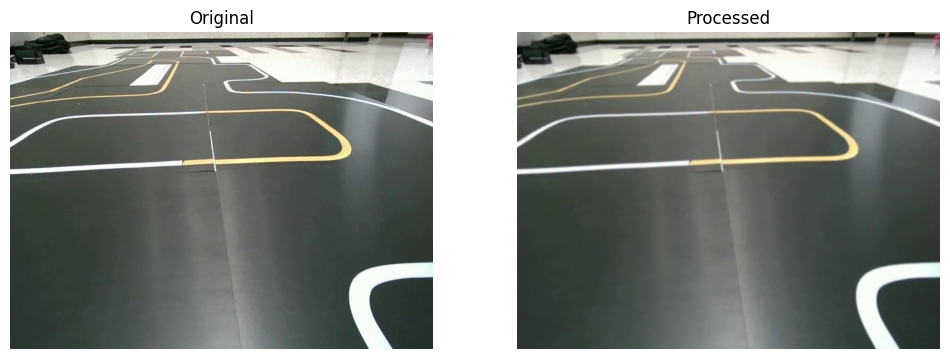

In [217]:

img = cv2.imread(image_path)
ori_img = img

if img is None: 
    print(f'이미지를 열 수 없음: {image_path}')
else:
    print(f'이미지 열기 성공: {image_path}')


img = cv2.resize(img, (640, 480))  # 크기 조정
img = cv2.GaussianBlur(img, (5, 5), 0)  # 노이즈 제거

showimg(ori_img, img)

색공간 변환 HLS, HSV 색공간을 통한 마스킹, 이진화

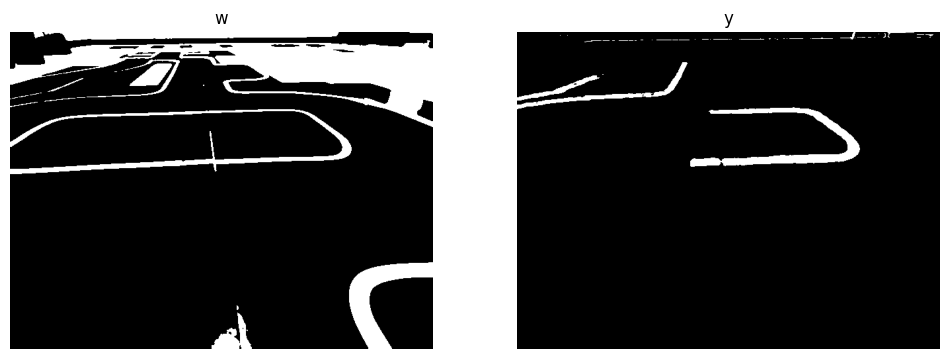

In [219]:
#색공간 변경 HLS로 white 검출, HSV로 노란색 차선 검출
hls = cv2.cvtColor(img, cv2.COLOR_BGR2HLS)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# 흰색 차선 (HLS) - 높은 L = 흰색
lower_white = np.array([0, 150, 0])
upper_white = np.array([180, 255, 255])
mask_white = cv2.inRange(hls, lower_white, upper_white)

# 노란색 차선 (HSV) - 10~40의 H 노란색
lower_yellow = np.array([10, 50, 50])
upper_yellow = np.array([40, 255, 255])
mask_yellow = cv2.inRange(hsv, lower_yellow, upper_yellow)

showimg(mask_white,mask_yellow, 'w', 'y')



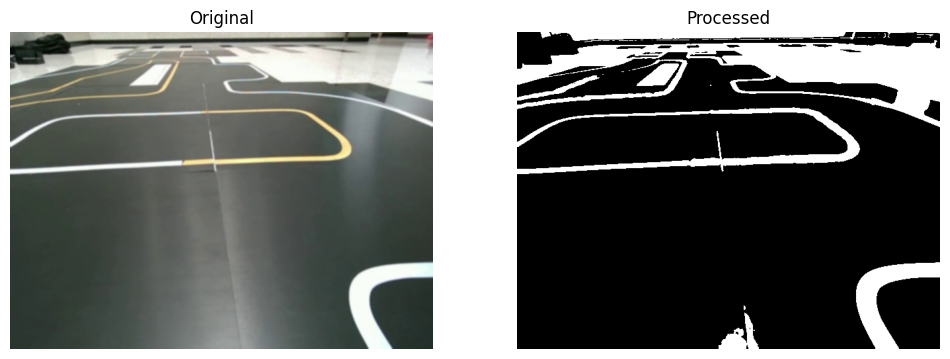

In [220]:
mask_lane = cv2.bitwise_or(mask_white,mask_yellow)
showimg(img,mask_lane)

edge 검출


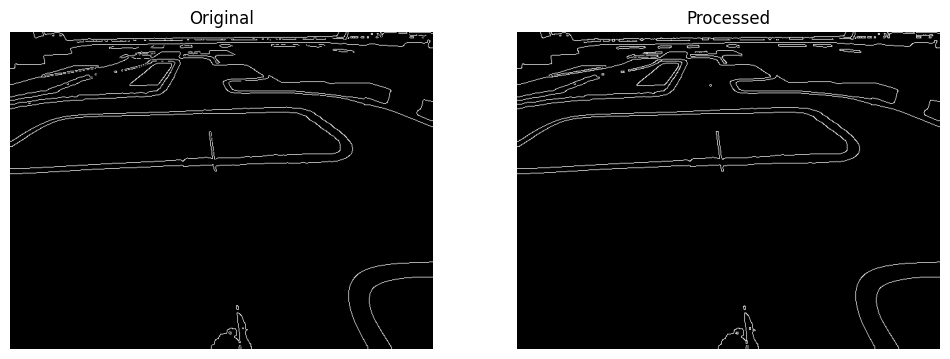

In [221]:
temp = mask_lane
temp = cv2.GaussianBlur(temp, (3, 3), 0)  # 노이즈 제거
temp = cv2.Canny(temp, 50, 150)
mask_lane = cv2.Canny(mask_lane, 50, 150)
showimg(mask_lane,temp)

###mouse_event 함수 (마우스를 클릭하는 방식으로 roi등 좌표값을 쉽게 return한다)

ROI 지정 (사다리꼴 마스크 > bitand연산) - 마우스 이벤트 없이 수동으로 

(480, 640)


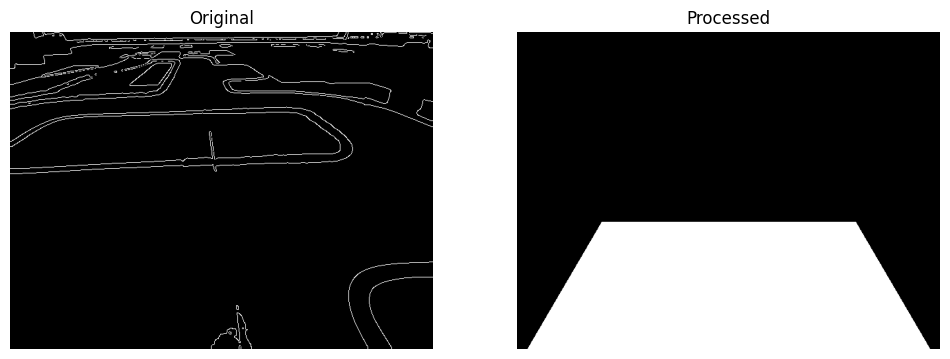

In [222]:

print(mask_lane.shape) # heigh,width 튜플을 반환
h , w = mask_lane.shape

w_ratio_1 = 0.95  #roi mask가 전체 가로에서 얼마나 차지할지 비율 지정, 사다리꼴의 밑변 비율
w_ratio_2 = 0.6  #roi mask가 전체 가로에서 얼마나 차지할지 비율 지정, 사다리꼴의 윗변 비율
h_ratio = 0.6  #roi mask가 전체 세로에서 얼마나 차지할지 비율 지정

# opecn마스크는 좌상단이 원점임 x는 우측으로 증가, y는 아래로 증가

bottom_left_x = int(w * ((1 - w_ratio_1)/2))
bottom_right_x = int( w * ((1 + w_ratio_1)/2))

top_left_x = int(w * ((1 - w_ratio_2)/2))
top_right_x = int(w * ((1 + w_ratio_2)/2))

bottom_y = h
top_y = h * h_ratio


roi_point = np.array([
    [bottom_left_x, bottom_y], # 좌하단
    [ top_left_x, top_y ], # 좌상단
    [top_right_x, top_y], #우상단
    [bottom_right_x , bottom_y] # 우하단
    
], dtype = np.int32)


# 전부 0인 마스크 생성
roi_mask = np.zeros((h,w), dtype = np.uint8)
# 255로 채우기
cv2.fillPoly(roi_mask, [roi_point], 255)

showimg(mask_lane,roi_mask)


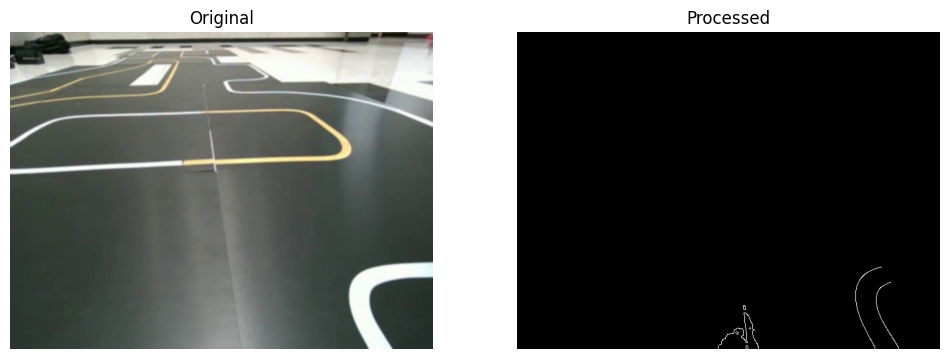

In [223]:
roi_img = cv2.bitwise_and(mask_lane, roi_mask)
showimg(img,roi_img)

ROISelector 사용 ROI

In [224]:
class ROISelector:
    def __init__(self, window_name, image):
        self.window_name = window_name
        self.image = image.copy()
        self.clone = image.copy()
        self.points = []
        self.done = False
        
        cv2.namedWindow(self.window_name)
        cv2.setMouseCallback(self.window_name, self.mouse_event)
    
    def mouse_event(self, event, x, y, flags, param):
        # 마우스 좌클릭 시 좌표 저장 및 표시
        if event == cv2.EVENT_LBUTTONDOWN:
            if len(self.points) < 4:
                self.points.append((x, y))
                cv2.circle(self.image, (x, y), 5, (0, 255, 0), -1)
                cv2.putText(self.image, f"{len(self.points)}", (x+10, y-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
                cv2.imshow(self.window_name, self.image)
            if len(self.points) == 4:
                self.done = True
    
    def get_points(self):
        # ROI 선택 완료 시 좌표 반환
        while not self.done:
            cv2.imshow(self.window_name, self.image)
            key = cv2.waitKey(1) & 0xFF
            # ESC 키 눌러서 종료 가능
            if key == 27:
                break
        
        cv2.destroyWindow(self.window_name)
        return self.points

# 사용 예시

selector = ROISelector("Select ROI - Click 4 points", img)
    
roi_points = selector.get_points() #좌하단 좌상단 우상단 우하단을 순서대로 클릭
    
if len(roi_points) == 4:
    print("Selected points:", roi_points)
else:
    print("ROI selection cancelled or incomplete")


QObject::moveToThread: Current thread (0xcfe0be0) is not the object's thread (0xfa97570).
Cannot move to target thread (0xcfe0be0)

QObject::moveToThread: Current thread (0xcfe0be0) is not the object's thread (0xfa97570).
Cannot move to target thread (0xcfe0be0)

QObject::moveToThread: Current thread (0xcfe0be0) is not the object's thread (0xfa97570).
Cannot move to target thread (0xcfe0be0)

QObject::moveToThread: Current thread (0xcfe0be0) is not the object's thread (0xfa97570).
Cannot move to target thread (0xcfe0be0)

QObject::moveToThread: Current thread (0xcfe0be0) is not the object's thread (0xfa97570).
Cannot move to target thread (0xcfe0be0)

QObject::moveToThread: Current thread (0xcfe0be0) is not the object's thread (0xfa97570).
Cannot move to target thread (0xcfe0be0)

QObject::moveToThread: Current thread (0xcfe0be0) is not the object's thread (0xfa97570).
Cannot move to target thread (0xcfe0be0)

QObject::moveToThread: Current thread (0xcfe0be0) is not the object's thread

Selected points: [(71, 267), (597, 242), (638, 474), (15, 475)]


[[ 71 267]
 [597 242]
 [638 474]
 [ 15 475]]


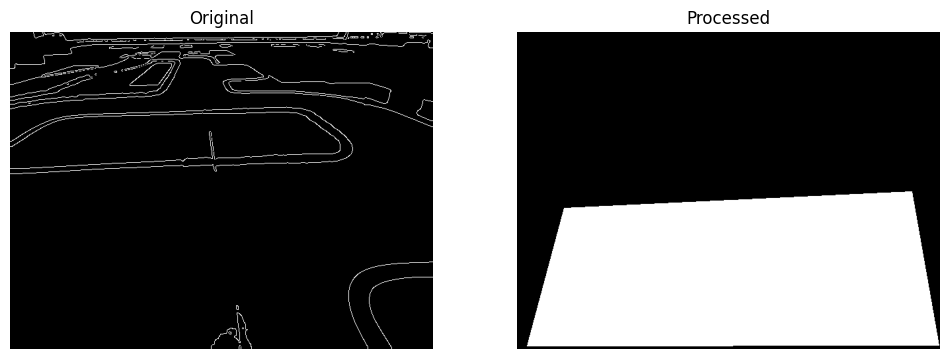

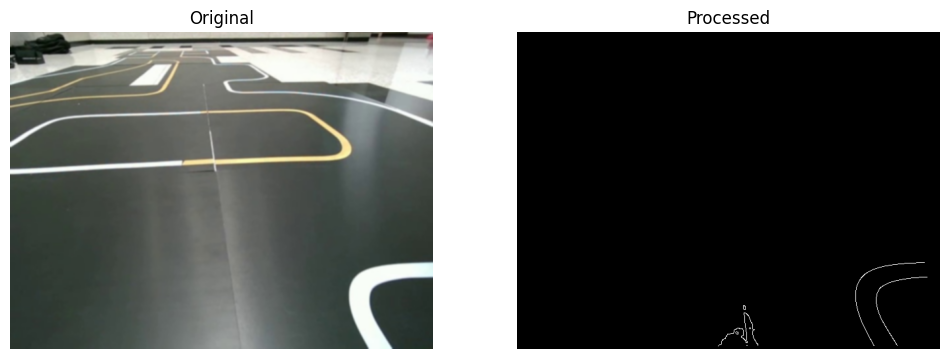

In [225]:
roi_ary = np.array(roi_points, dtype = np.int32)
print(roi_ary)

h , w = mask_lane.shape
# 전부 0인 마스크 생성
roi_mask = np.zeros((h,w), dtype = np.uint8)
# 255로 채우기
cv2.fillPoly(roi_mask, [roi_ary], 255)

showimg(mask_lane,roi_mask)
roi_img_use = cv2.bitwise_and(mask_lane, roi_mask)
showimg(img,roi_img_use)

# 마우스 이벤트를 보완하여, 클릭한 지점을 raw한 값이 아닌 보정된 값으로 가져오게 한다.
# 좌상단 우상단 우하단 좌하단

In [226]:
class ROISelector:
    def __init__(self, window_name, image):
        self.window_name = window_name
        self.image = image.copy()
        self.clone = image.copy()
        self.points = []
        self.done = False
        
        cv2.namedWindow(self.window_name)
        cv2.setMouseCallback(self.window_name, self.mouse_event)
    
    def mouse_event(self, event, x, y, flags, param):
        # 마우스 좌클릭 시 좌표 저장 및 표시
        if event == cv2.EVENT_LBUTTONDOWN:
            if len(self.points) < 4:
                self.points.append((x, y))
                cv2.circle(self.image, (x, y), 5, (0, 255, 0), -1)
                cv2.putText(self.image, f"{len(self.points)}", (x+10, y-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
                cv2.imshow(self.window_name, self.image)
            if len(self.points) == 4:
                self.done = True
    
    def get_points(self):
        # ROI 선택 완료 시 좌표 반환
        while not self.done:
            cv2.imshow(self.window_name, self.image)
            key = cv2.waitKey(1) & 0xFF
            # ESC 키 눌러서 종료 가능
            if key == 27:
                break
        
        cv2.destroyWindow(self.window_name)
        return self.points

# 사용 예시

selector = ROISelector("Select ROI - Click 4 points", img)
    
roi_points = selector.get_points() #좌하단 좌상단 우상단 우하단을 순서대로 클릭
    
if len(roi_points) == 4:
    print("Selected points:", roi_points)
else:
    print("ROI selection cancelled or incomplete")



roi_ary = np.array(roi_points, dtype = np.int32)
print(roi_ary)


QObject::moveToThread: Current thread (0xcfe0be0) is not the object's thread (0xfa97570).
Cannot move to target thread (0xcfe0be0)

QObject::moveToThread: Current thread (0xcfe0be0) is not the object's thread (0xfa97570).
Cannot move to target thread (0xcfe0be0)

QObject::moveToThread: Current thread (0xcfe0be0) is not the object's thread (0xfa97570).
Cannot move to target thread (0xcfe0be0)

QObject::moveToThread: Current thread (0xcfe0be0) is not the object's thread (0xfa97570).
Cannot move to target thread (0xcfe0be0)

QObject::moveToThread: Current thread (0xcfe0be0) is not the object's thread (0xfa97570).
Cannot move to target thread (0xcfe0be0)

QObject::moveToThread: Current thread (0xcfe0be0) is not the object's thread (0xfa97570).
Cannot move to target thread (0xcfe0be0)

QObject::moveToThread: Current thread (0xcfe0be0) is not the object's thread (0xfa97570).
Cannot move to target thread (0xcfe0be0)

QObject::moveToThread: Current thread (0xcfe0be0) is not the object's thread

Selected points: [(70, 290), (598, 281), (628, 475), (21, 475)]
[[ 70 290]
 [598 281]
 [628 475]
 [ 21 475]]


[[ 70 285]
 [598 285]
 [628 475]
 [ 21 475]]
(480, 640)


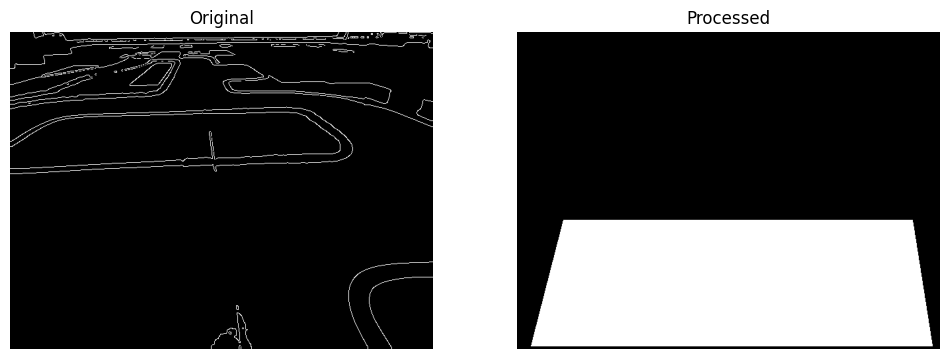

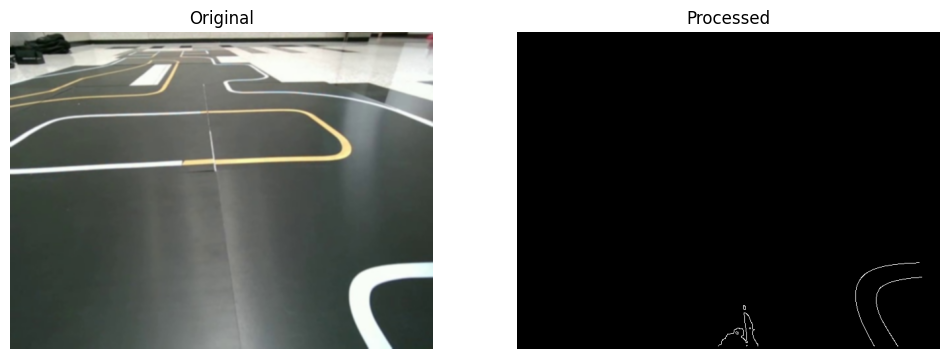

In [227]:
temp_y1 = int(( roi_ary[0,1] + roi_ary[1,1] ) / 2 )
temp_y2 = int(( roi_ary[2,1] + roi_ary[3,1] ) / 2 )
roi_ary[0,1] = temp_y1
roi_ary[1,1] = temp_y1

roi_ary[2,1] = temp_y2
roi_ary[3,1] = temp_y2

print(roi_ary)
print(mask_lane.shape)
h , w = mask_lane.shape
# 전부 0인 마스크 생성
roi_mask = np.zeros((h,w), dtype = np.uint8)
# 255로 채우기
cv2.fillPoly(roi_mask, [roi_ary], 255)

showimg(mask_lane,roi_mask)
roi_img_use = cv2.bitwise_and(mask_lane, roi_mask)
showimg(img,roi_img_use)

# bird_eye_View 변환

In [228]:
# bird_eye_View 변환
img_conv = roi_img_use

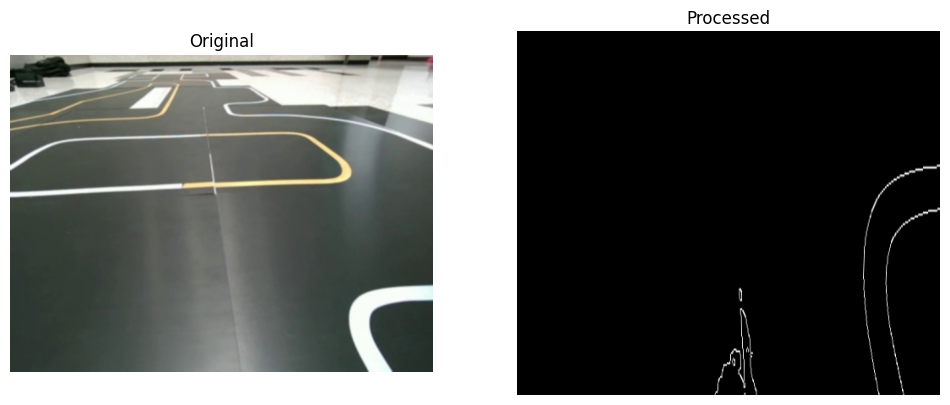

In [229]:

# bird's eye view를 적용할 roi를 받아옴 (좌상단 우상한 우하단 좌하단)
src = roi_ary.astype(np.float32)


# 변환할 직사각형 영역 정의
width, height = 500, 430
dst = np.float32([[0, 0], [width, 0], [width, height], [0, height]]) #시계방향 포인트 지정

# 투시 변환 행렬 계산
M = cv2.getPerspectiveTransform(src, dst)

# 원근 변환 적용
bird_eye_view = cv2.warpPerspective(img_conv, M, (width, height))

# 결과 출력
showimg(img,bird_eye_view)


# 슬라이딩 윈도우 알고리즘 차선검출

버드아이뷰 변환된 이진(binarized) 이미지에서 각 열의 흰색 픽셀(차선으로 예상되는 부분) 수를 히스토그램으로 계산한다.

히스토그램을 기준으로 왼쪽과 오른쪽 차선 위치의 시작점(x 좌표)을 찾는다. 주로 이미지 아래쪽에서 높이 방향으로 시작

일정 크기의 윈도우(사각형 박스)를 이미지 아래쪽부터 시작점 주변에 생성한다.

윈도우 내부에서 흰색 픽셀들을 찾아 그 중심점들의 평균 x 좌표를 구한다.

이 평균 x 좌표를 기준으로 윈도우를 윗방향(이미지 위쪽)으로 조금씩 슬라이딩(이동)하며 차선 영역을 따라가며 추적한다.

모든 윈도우를 다 지나면 왼쪽/오른쪽 차선 점들의 좌표가 쌓여 각각 차선 곡선을 근사(fitting)할 수 있다.

이 방법은 곡선 차선도 따라갈 수 있고 노이즈 내성도 비교적 강한 기법이다.

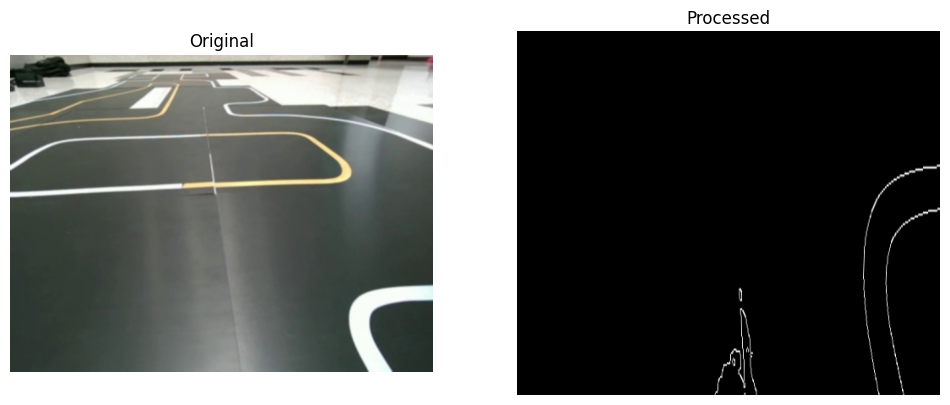

In [230]:
# 슬라이딩 윈도우 알고리즘 차선검출
img_conv = bird_eye_view
showimg(img,img_conv)

In [231]:
# 왼쪽, 오른쪽 베이스 위치
histogram = np.sum(img_conv[img_conv.shape[0]//2:,:], axis=0)
midpoint = histogram.shape[0]//2
leftx_base = np.argmax(histogram[:midpoint])
rightx_base = np.argmax(histogram[midpoint:]) + midpoint

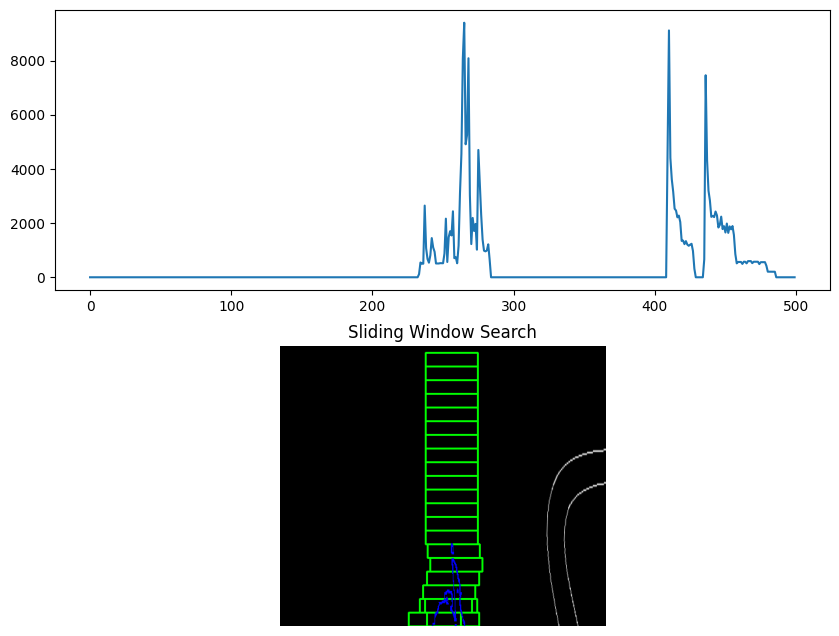

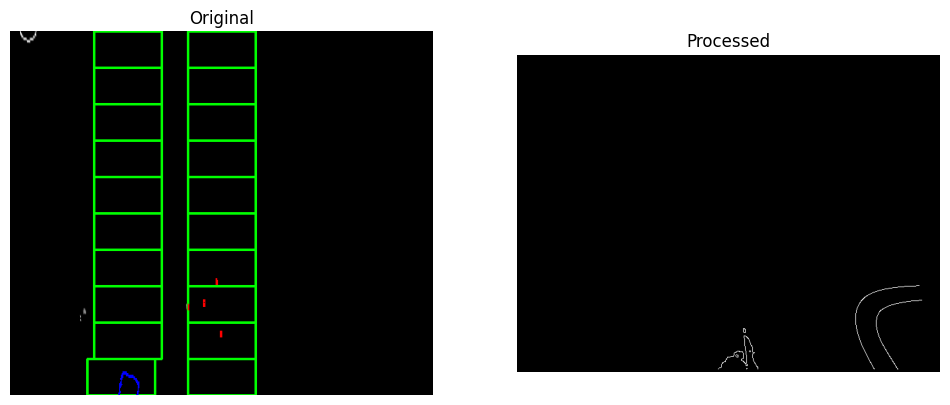

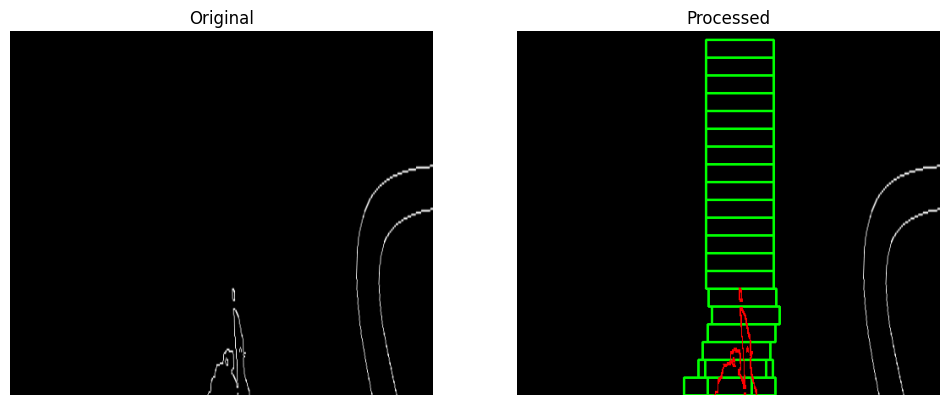

In [287]:
# 버드아이뷰 이진 이미지 (0,255)
binary_warped = img_conv  # 예: cv2.imread('bird_eye_binary.jpg', 0)

# 히스토그램 계산
histogram = np.sum(binary_warped[binary_warped.shape[0]//2:,:], axis=0)

# 베이스 위치 찾기
midpoint = histogram.shape[0]//2
leftx_base = np.argmax(histogram[:midpoint])
rightx_base = np.argmax(histogram[midpoint:]) + midpoint

# 슬라이딩 윈도우 설정
nwindows = 20
window_height = binary_warped.shape[0] // nwindows
margin = 40
minpix = 50

leftx_current = leftx_base
rightx_current = rightx_base

nonzero = binary_warped.nonzero()
nonzeroy = np.array(nonzero[0])
nonzerox = np.array(nonzero[1])

left_lane_inds = []
right_lane_inds = []

# 원본 이진 이미지 컬러로 변환 (윈도우 박스 그리기용)
out_img = np.dstack((binary_warped, binary_warped, binary_warped))

for window in range(nwindows):
    win_y_low = binary_warped.shape[0] - (window+1)*window_height
    win_y_high = binary_warped.shape[0] - window*window_height

    win_xleft_low = leftx_current - margin
    win_xleft_high = leftx_current + margin
    win_xright_low = rightx_current - margin
    win_xright_high = rightx_current + margin

    # 윈도우 사각형 그리기
    cv2.rectangle(out_img, (win_xleft_low, win_y_low), (win_xleft_high, win_y_high), (0,255,0), 2)
    cv2.rectangle(out_img, (win_xright_low, win_y_low), (win_xright_high, win_y_high), (0,255,0), 2)

    # 윈도우 내 픽셀 인덱스 추출
    good_left_inds = ((nonzeroy >= win_y_low) & (nonzeroy < win_y_high) &
                      (nonzerox >= win_xleft_low) & (nonzerox < win_xleft_high)).nonzero()[0]
    good_right_inds = ((nonzeroy >= win_y_low) & (nonzeroy < win_y_high) &
                       (nonzerox >= win_xright_low) & (nonzerox < win_xright_high)).nonzero()[0]

    left_lane_inds.append(good_left_inds)
    right_lane_inds.append(good_right_inds)

    if len(good_left_inds) > minpix:
        leftx_current = int(np.mean(nonzerox[good_left_inds]))
    if len(good_right_inds) > minpix:
        rightx_current = int(np.mean(nonzerox[good_right_inds]))

# 차선 픽셀 좌표 결합
left_lane_inds = np.concatenate(left_lane_inds)
right_lane_inds = np.concatenate(right_lane_inds)

# 차선 픽셀 색칠
out_img[nonzeroy[left_lane_inds], nonzerox[left_lane_inds]] = [255, 0, 0]
out_img[nonzeroy[right_lane_inds], nonzerox[right_lane_inds]] = [0, 0, 255]

# 히스토그램과 결과 이미지 시각화
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,8))

# 히스토그램ㅇ
ax1.plot(histogram)

# 슬라이딩 윈도우 결과 이미지
ax2.imshow(out_img)
ax2.set_title('Sliding Window Search')
ax2.axis('off')

#plt.tight_layout()
#plt.show()

showimg(img,roi_img_use)
showimg(bird_eye_view,out_img)


##함수화

In [313]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
from typing import List, Optional, Union, Dict, Tuple, Callable


def process_img_1( #색공간을 활용한
    img: np.ndarray,
    Gaussain_kernel_size : int = 7,
    white_thresh: Tuple[np.ndarray, np.ndarray] = (np.array([0, 200, 0]), np.array([180, 255, 255])),
    yellow_thresh: Tuple[np.ndarray, np.ndarray] = (np.array([10, 50, 50]), np.array([40, 255, 255]))
) -> np.ndarray:
    """
    매개변수 img는 shape (H, W, 3), dtype uint8의 컬러 이미지입니다.
    """

    if img is None: 
        raise ValueError("이미지가 입력되지 않음")
    if Gaussain_kernel_size % 2 == 0 :
        raise ValueError("가우시안 커널은 홀수여야만 합니다.")
        

    img = cv2.resize(img, (640, 480))  # 크기 조정
    img = cv2.GaussianBlur(img, (Gaussain_kernel_size, Gaussain_kernel_size), 0)  # 노이즈 제거

    #색공간 변경 HLS로 white 검출, HSV로 노란색 차선 검출
    hls = cv2.cvtColor(img, cv2.COLOR_BGR2HLS)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # 흰색 차선 (HLS) - 높은 L = 흰색
    mask_white = cv2.inRange(hls, white_thresh[0], white_thresh[1])

    # 노란색 차선 (HSV) - 10~40의 H 노란색
    mask_yellow = cv2.inRange(hsv, yellow_thresh[0], yellow_thresh[1])

    #showimg(mask_white,mask_yellow)

    img_conv = cv2.bitwise_or(mask_white,mask_yellow)
    img_conv = cv2.Canny(img_conv, 50, 150)

    return img_conv

def process_img_2( #roi / bird's eyes view
    img: np.ndarray,
    roi_nparry : np.ndarray,
    bev_roi_nparry : np.ndarray,
    bev_dst : Tuple[int,int] = (500,430)
) -> np.ndarray:
    """
    매개변수 img는 shape (H, W, 3), dtype uint8의 컬러 이미지입니다.
    """

    if img is None: 
        raise ValueError("이미지가 입력되지 않음")

    h , w = img.shape
    # 전부 0인 마스크 생성
    roi_mask = np.zeros((h,w), dtype = np.uint8)
    # 255로 채우기
    cv2.fillPoly(roi_mask, [roi_nparry], 255)
    img_conv = cv2.bitwise_and(img, roi_mask)
    #showimg(img,img_conv)   


    src = bev_roi_nparry.astype(np.float32)
    width, height = bev_dst
    dst = np.float32([[0, 0], [width, 0], [width, height], [0, height]]) #시계방향 포인트 지정

    # 투시 변환 행렬 계산
    M = cv2.getPerspectiveTransform(src, dst)

    # 원근 변환 적용
    img_conv = cv2.warpPerspective(img_conv, M, (width, height))
    # 결과 출력
    #showimg(img,img_conv)
    
    return img_conv
def init_kalman():
    kf = cv2.KalmanFilter(3, 3)
    kf.transitionMatrix = np.eye(3, dtype=np.float32)
    kf.measurementMatrix = np.eye(3, dtype=np.float32)
    kf.processNoiseCov = np.eye(3, dtype=np.float32) * 1e-4
    kf.measurementNoiseCov = np.eye(3, dtype=np.float32) * 1e-2
    kf.errorCovPost = np.eye(3, dtype=np.float32)
    kf.statePost = np.zeros((3,1), dtype=np.float32)
    return kf

def update_kalman(kf, measured_coeffs):
    kf.predict()
    measurement = np.array(measured_coeffs, dtype=np.float32).reshape(-1,1)
    estimate = kf.correct(measurement)
    return estimate.flatten()

# ======================
# 슬라이딩 윈도우 / Search Around Poly
# ======================
def sliding_window_search_around(
    img: np.ndarray,
    left_kf,
    right_kf,
    left_fit_prev=None,
    right_fit_prev=None,
    num_windows: int = 10,
    margin: int = 40,
    minpix: int = 50,
    lane_width_pixels: int = 380
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:

    # 히스토그램 기반 초기화
    histogram = np.sum(img[img.shape[0]//2:,:], axis=0)
    midpoint = histogram.shape[0]//2
    leftx_base = np.argmax(histogram[:midpoint])
    rightx_base = np.argmax(histogram[midpoint:]) + midpoint

    window_height = img.shape[0] // num_windows
    nonzero = img.nonzero()
    nonzeroy = np.array(nonzero[0])
    nonzerox = np.array(nonzero[1])

    left_lane_inds, right_lane_inds = [], []

    out_img = np.dstack((img, img, img)).astype(np.uint8)

    # ======================
    # Search Around Poly
    # ======================
    if left_fit_prev is not None and right_fit_prev is not None:
        # 이전 poly 기준으로 margin 내 픽셀만 탐색
        left_lane_inds = ((nonzerox > (left_fit_prev[0]*nonzeroy**2 +
                                        left_fit_prev[1]*nonzeroy +
                                        left_fit_prev[2] - margin)) &
                          (nonzerox < (left_fit_prev[0]*nonzeroy**2 +
                                        left_fit_prev[1]*nonzeroy +
                                        left_fit_prev[2] + margin)))

        right_lane_inds = ((nonzerox > (right_fit_prev[0]*nonzeroy**2 +
                                        right_fit_prev[1]*nonzeroy +
                                        right_fit_prev[2] - margin)) &
                           (nonzerox < (right_fit_prev[0]*nonzeroy**2 +
                                        right_fit_prev[1]*nonzeroy +
                                        right_fit_prev[2] + margin)))

        left_lane_inds = nonzeroy[left_lane_inds.nonzero()[0]], nonzerox[left_lane_inds.nonzero()[0]]
        right_lane_inds = nonzeroy[right_lane_inds.nonzero()[0]], nonzerox[right_lane_inds.nonzero()[0]]
    else:
        # 초기화: 기존 슬라이딩 윈도우
        leftx_current, rightx_current = leftx_base, rightx_base
        left_centers_y, left_centers_x = [], []
        right_centers_y, right_centers_x = [], []

        for window in range(num_windows):
            win_y_low = img.shape[0] - (window+1)*window_height
            win_y_high = img.shape[0] - window*window_height
            win_xleft_low = leftx_current - margin
            win_xleft_high = leftx_current + margin
            win_xright_low = rightx_current - margin
            win_xright_high = rightx_current + margin

            # 윈도우 내 픽셀 추출
            good_left_inds = ((nonzeroy >= win_y_low) & (nonzeroy < win_y_high) &
                              (nonzerox >= win_xleft_low) & (nonzerox < win_xleft_high)).nonzero()[0]
            good_right_inds = ((nonzeroy >= win_y_low) & (nonzeroy < win_y_high) &
                               (nonzerox >= win_xright_low) & (nonzerox < win_xright_high)).nonzero()[0]

            left_lane_inds.append(good_left_inds)
            right_lane_inds.append(good_right_inds)

            if len(good_left_inds) > minpix:
                weights = img.shape[0] - nonzeroy[good_left_inds]
                leftx_current = int(np.average(nonzerox[good_left_inds], weights=weights))

            if len(good_right_inds) > minpix:
                weights = img.shape[0] - nonzeroy[good_right_inds]
                rightx_current = int(np.average(nonzerox[good_right_inds], weights=weights))

        left_lane_inds = np.concatenate(left_lane_inds)
        right_lane_inds = np.concatenate(right_lane_inds)

    leftx = nonzerox[left_lane_inds]
    lefty = nonzeroy[left_lane_inds]
    rightx = nonzerox[right_lane_inds]
    righty = nonzeroy[right_lane_inds]

    # ======================
    # 다항 피팅
    # ======================
    left_fit, right_fit = None, None
    if len(leftx) > 0 and len(lefty) > 0:
        left_fit = np.polyfit(lefty, leftx, 2)
    if len(rightx) > 0 and len(righty) > 0:
        right_fit = np.polyfit(righty, rightx, 2)

    # ======================
    # 한쪽 라인 결손 시 추정
    # ======================
    if left_fit is not None and right_fit is None:
        right_fit = left_fit.copy()
        right_fit[2] += lane_width_pixels
    elif right_fit is not None and left_fit is None:
        left_fit = right_fit.copy()
        left_fit[2] -= lane_width_pixels

    # ======================
    # 칼만필터 안정화
    # ======================
    if left_fit is not None:
        left_fit = update_kalman(left_kf, left_fit)
    if right_fit is not None:
        right_fit = update_kalman(right_kf, right_fit)

    # ======================
    # 시각화
    # ======================
    ploty = np.linspace(0, img.shape[0]-1, img.shape[0])
    if left_fit is not None:
        left_fitx = left_fit[0]*ploty**2 + left_fit[1]*ploty + left_fit[2]
        for i in range(len(ploty)):
            cv2.circle(out_img, (int(left_fitx[i]), int(ploty[i])), 1, (255,255,0), -1)

    if right_fit is not None:
        right_fitx = right_fit[0]*ploty**2 + right_fit[1]*ploty + right_fit[2]
        for i in range(len(ploty)):
            cv2.circle(out_img, (int(right_fitx[i]), int(ploty[i])), 1, (255,255,0), -1)

    # y좌표 벡터
    ploty = np.linspace(0, img.shape[0]-1, img.shape[0])

    # 왼쪽, 오른쪽 x좌표
    left_fitx = left_fit[0]*ploty**2 + left_fit[1]*ploty + left_fit[2]
    right_fitx = right_fit[0]*ploty**2 + right_fit[1]*ploty + right_fit[2]

    # 차선 중심선
    center_fitx = (left_fitx + right_fitx) / 2

    return out_img, left_fit, right_fit, center_fitx

left_kf = init_kalman()
right_kf = init_kalman()



In [315]:
script_dir = os.getcwd()
# script_dir = os.path.dirname(os.path.abspath(__file__))
#image_path = os.path.join(script_dir,'data/line_avi_dataset/data/images/train/extracted_20f','01_0015.jpg')

video_path = os.path.join(script_dir,'data/line_avi_dataset/data/videos/train', '01.avi')

cap = cv2.VideoCapture(video_path)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # 프레임별 처리 순서 — 필요에 따라 ROI 좌표 지정
    roi_ary = np.array([[70, 290],[598, 281],[628, 475],[ 21, 475]], dtype=np.int32)
    
    frame_processed_1 = process_img_1(frame)
    frame_processed_2 = process_img_2(frame_processed_1, roi_ary, roi_ary)
    img, _, _, c = sliding_window_search_around(frame_processed_2)
    print(c)
    # 결과 표시 (필요 시)
    cv2.imshow('Processed Frame', img)
    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

TypeError: sliding_window_search_around() missing 2 required positional arguments: 'left_kf' and 'right_kf'